In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import warnings, ccxt
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (14, 4), "axes.grid": True, "grid.alpha": 0.3})
print("Imports OK")

Imports OK


In [8]:
# ── Fetch daily OHLCV data for 5 cryptos via ccxt (Kraken) ───────────────────
EXCHANGE_NAME = "kraken"
exchange = getattr(ccxt, EXCHANGE_NAME)({"enableRateLimit": True})
exchange.load_markets()
print(f"Connected to {EXCHANGE_NAME}")

symbols = {
    "Bitcoin":  "BTC/USD",
    "Ethereum": "ETH/USD",
    "Solana":   "SOL/USD",
    "Dogecoin": "DOGE/USD",
    "XRP":      "XRP/USD",
}

def fetch_daily_ohlcv(exchange, symbol, since="2023-03-09", limit=720):
    """Fetch daily candles from Kraken and return a DataFrame."""
    since_ts = exchange.parse8601(since + "T00:00:00Z")
    all_ohlcv = []
    while True:
        ohlcv = exchange.fetch_ohlcv(symbol, timeframe="1d", since=since_ts, limit=limit)
        if not ohlcv:
            break
        all_ohlcv.extend(ohlcv)
        since_ts = ohlcv[-1][0] + 86_400_000  # next day
        if len(ohlcv) < limit:
            break
    df = pd.DataFrame(all_ohlcv, columns=["timestamp", "open", "high", "low", "close", "volume"])
    df["date"] = pd.to_datetime(df["timestamp"], unit="ms")
    df = df.set_index("date")[["open", "high", "low", "close", "volume"]]
    return df

# Fetch all
crypto_data = {}
for name, sym in symbols.items():
    crypto_data[name] = fetch_daily_ohlcv(exchange, sym)
    print(f"{name:10s}  shape={crypto_data[name].shape}  "
          f"range: {crypto_data[name].index.min().date()} -> {crypto_data[name].index.max().date()}")

print("\nAll data loaded")

Connected to kraken
Bitcoin     shape=(721, 5)  range: 2024-03-22 -> 2026-03-12
Ethereum    shape=(721, 5)  range: 2024-03-22 -> 2026-03-12
Solana      shape=(721, 5)  range: 2024-03-22 -> 2026-03-12
Dogecoin    shape=(721, 5)  range: 2024-03-22 -> 2026-03-12
XRP         shape=(721, 5)  range: 2024-03-22 -> 2026-03-12

All data loaded


In [9]:
# ── Build a combined close-price DataFrame (last 6 months) ───────────────────
close_df = pd.DataFrame({name: df["close"] for name, df in crypto_data.items()})
close_df = close_df.sort_index()

# Last 6 months of data
cutoff = close_df.index.max() - pd.DateOffset(months=6)
close_6m = close_df.loc[cutoff:]
print(f"6-month window: {close_6m.index.min().date()} -> {close_6m.index.max().date()}  ({len(close_6m)} days)")
close_6m.tail()

6-month window: 2025-09-12 -> 2026-03-12  (182 days)


,Bitcoin,Ethereum,Solana,Dogecoin,XRP
date,,,,,
2026-03-08,65978.7,1937.24,81.58,0.089106,1.34033
2026-03-09,68446.9,1994.57,85.00,0.090480,1.36320
2026-03-10,69955.4,2037.16,85.90,0.094519,1.38665
2026-03-11,70200.4,2052.18,86.58,0.092892,1.38454
2026-03-12,70072.2,2052.43,86.14,0.093151,1.38136


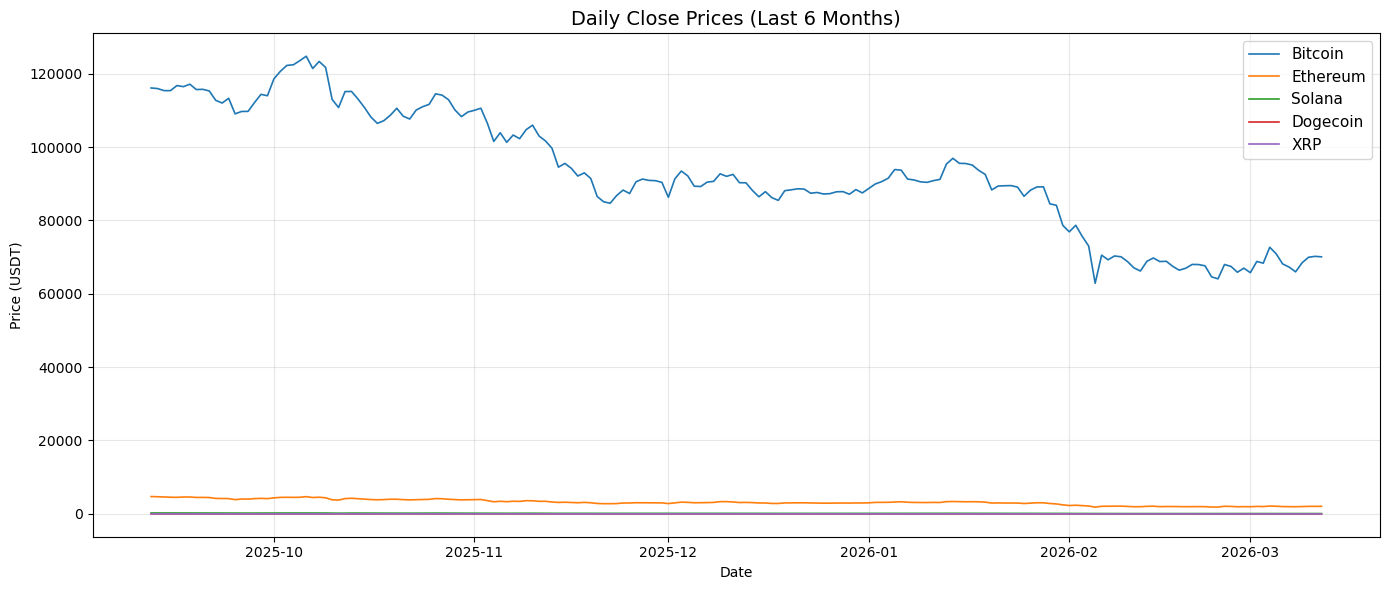

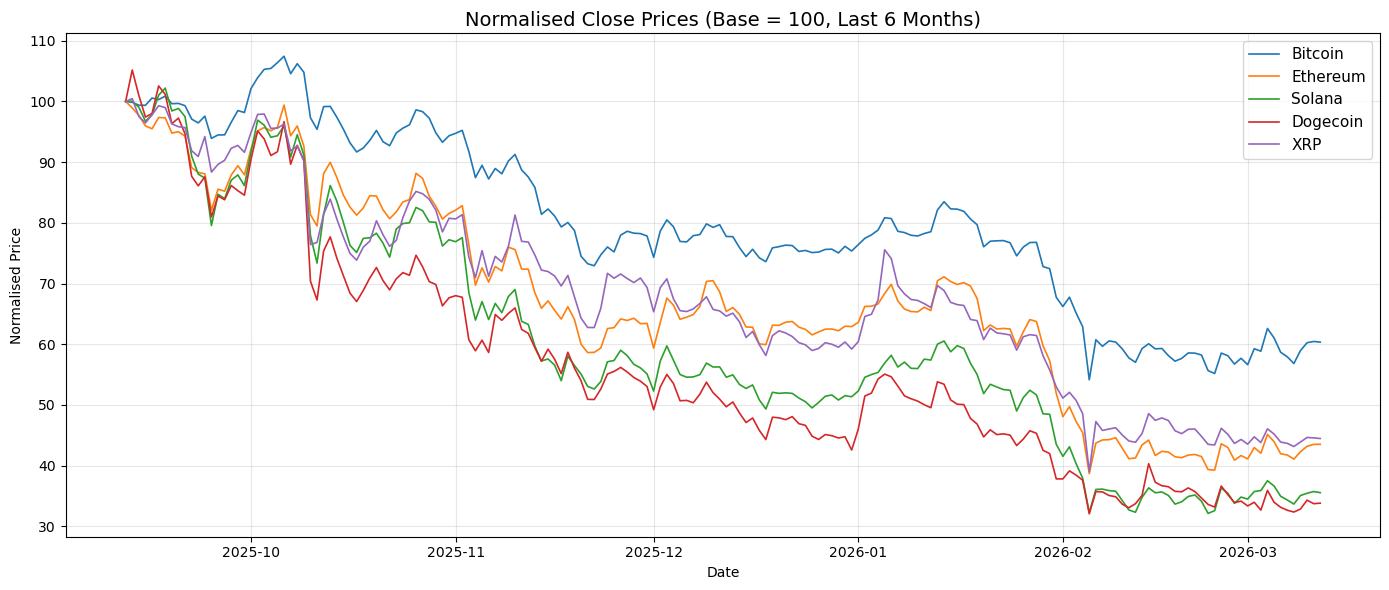

In [10]:
# ── Overlapping Daily Close Price Time Series (6 months) ─────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
for coin in close_6m.columns:
    ax.plot(close_6m.index, close_6m[coin], label=coin, linewidth=1.2)
ax.set_title("Daily Close Prices (Last 6 Months)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USDT)")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Normalised version (base=100) for easier shape comparison
norm_6m = close_6m / close_6m.iloc[0] * 100
fig, ax = plt.subplots(figsize=(14, 6))
for coin in norm_6m.columns:
    ax.plot(norm_6m.index, norm_6m[coin], label=coin, linewidth=1.2)
ax.set_title("Normalised Close Prices (Base = 100, Last 6 Months)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Normalised Price")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

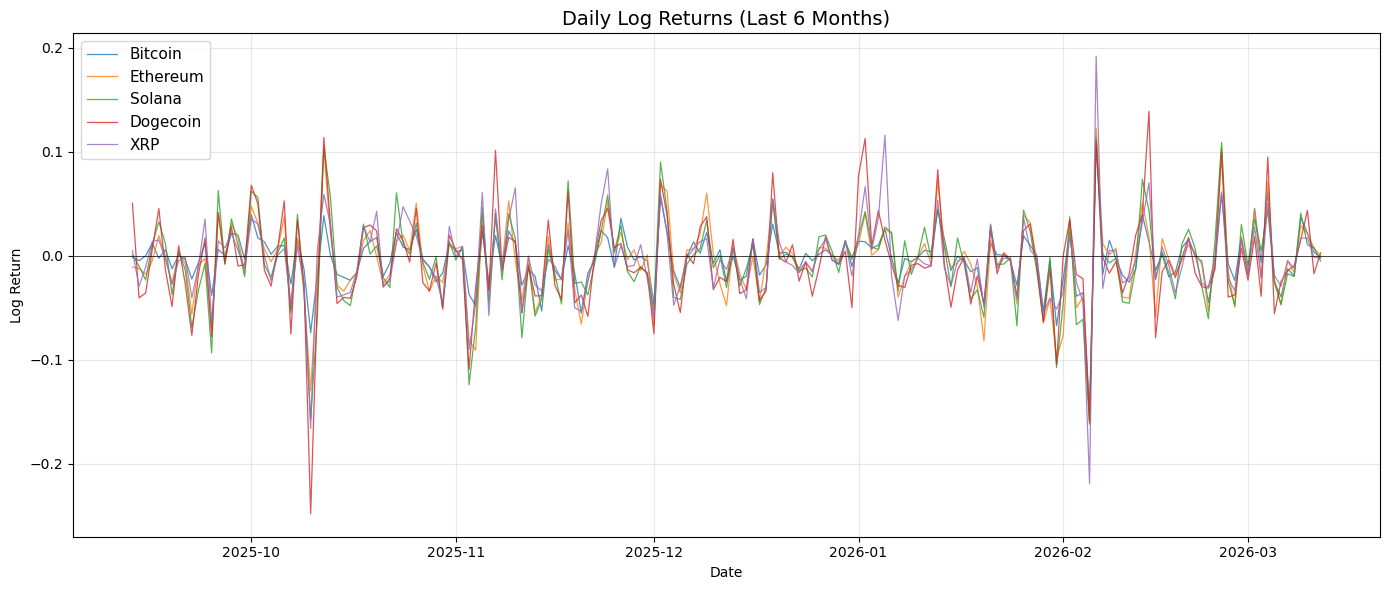

,count,mean,std,min,25%,50%,75%,max
Bitcoin,181.0,-0.002790,0.026246,-0.149766,-0.016497,-0.001526,0.011527,0.115121
Ethereum,181.0,-0.004597,0.037793,-0.161182,-0.023134,-0.002247,0.012180,0.122814
Solana,181.0,-0.005715,0.041368,-0.162122,-0.029419,-0.005095,0.016640,0.111710
Dogecoin,181.0,-0.005990,0.046053,-0.248406,-0.030706,-0.009335,0.017691,0.138912
XRP,181.0,-0.004477,0.039900,-0.219232,-0.025512,-0.004715,0.014280,0.191953


In [11]:
# ── Log Returns (6 months) ────────────────────────────────────────────────────
log_returns = np.log(close_6m / close_6m.shift(1)).dropna()

fig, ax = plt.subplots(figsize=(14, 6))
for coin in log_returns.columns:
    ax.plot(log_returns.index, log_returns[coin], label=coin, alpha=0.8, linewidth=0.9)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("Daily Log Returns (Last 6 Months)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Log Return")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Summary statistics
log_returns.describe().T

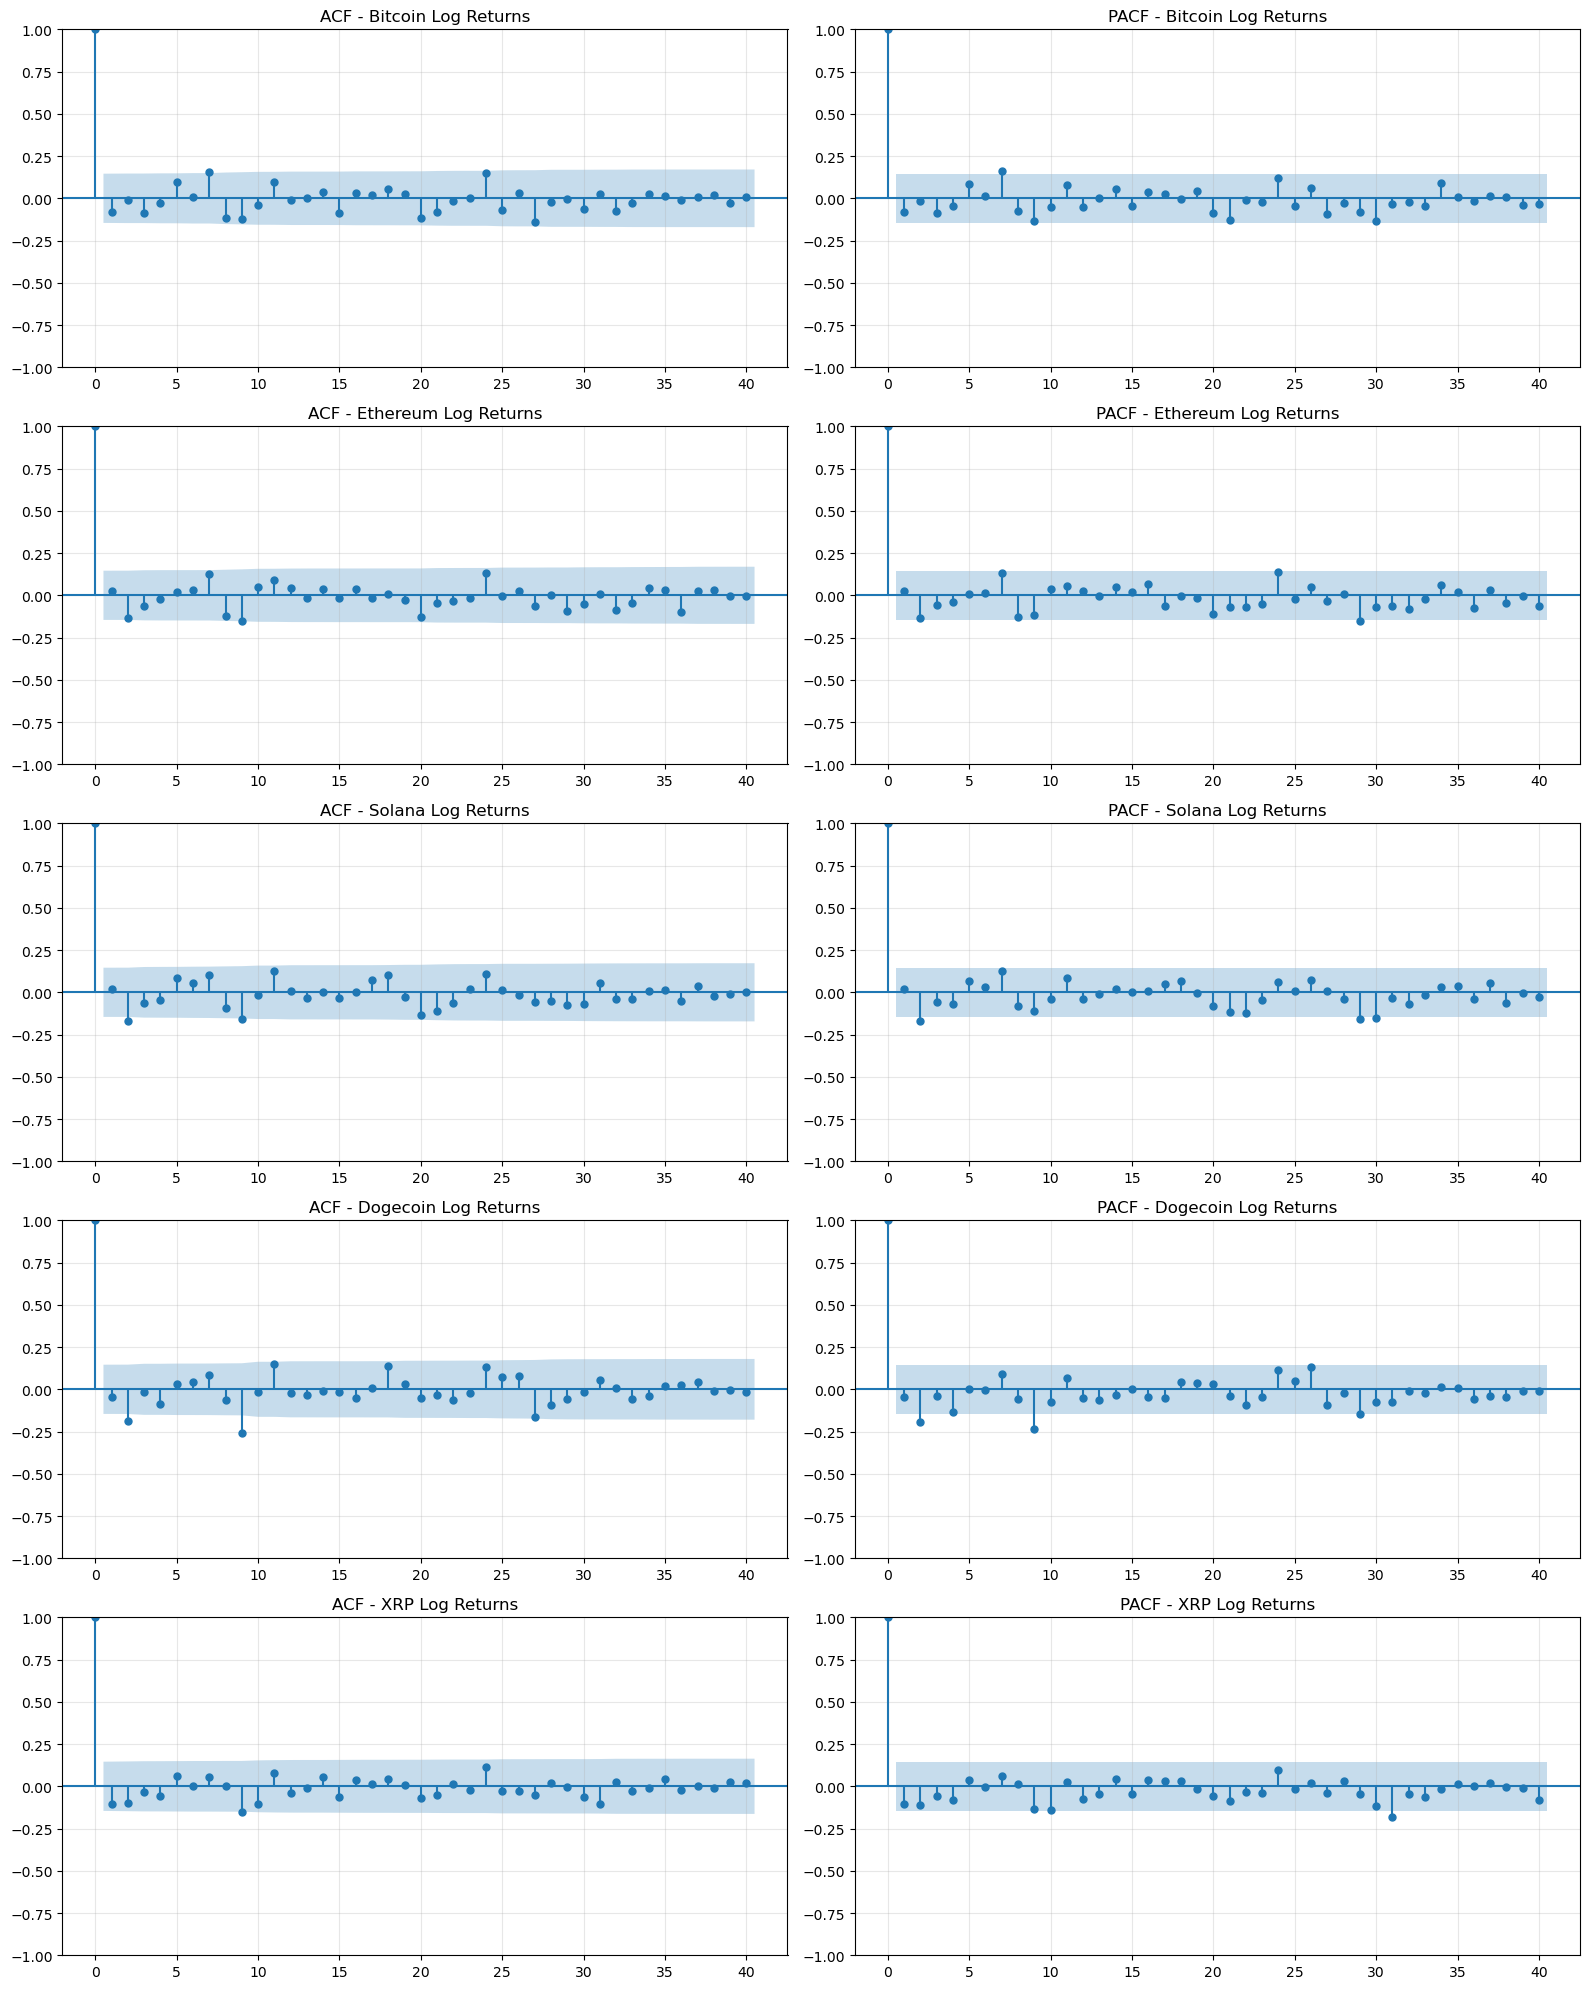

In [12]:
# ── ACF and PACF for each crypto's log returns ───────────────────────────────
n_lags = 40

fig, axes = plt.subplots(len(log_returns.columns), 2, figsize=(16, 4 * len(log_returns.columns)))

for i, coin in enumerate(log_returns.columns):
    series = log_returns[coin].dropna()
    plot_acf(series, lags=n_lags, ax=axes[i, 0], title=f"ACF - {coin} Log Returns")
    plot_pacf(series, lags=n_lags, ax=axes[i, 1], title=f"PACF - {coin} Log Returns", method="ywm")

plt.tight_layout()
plt.show()

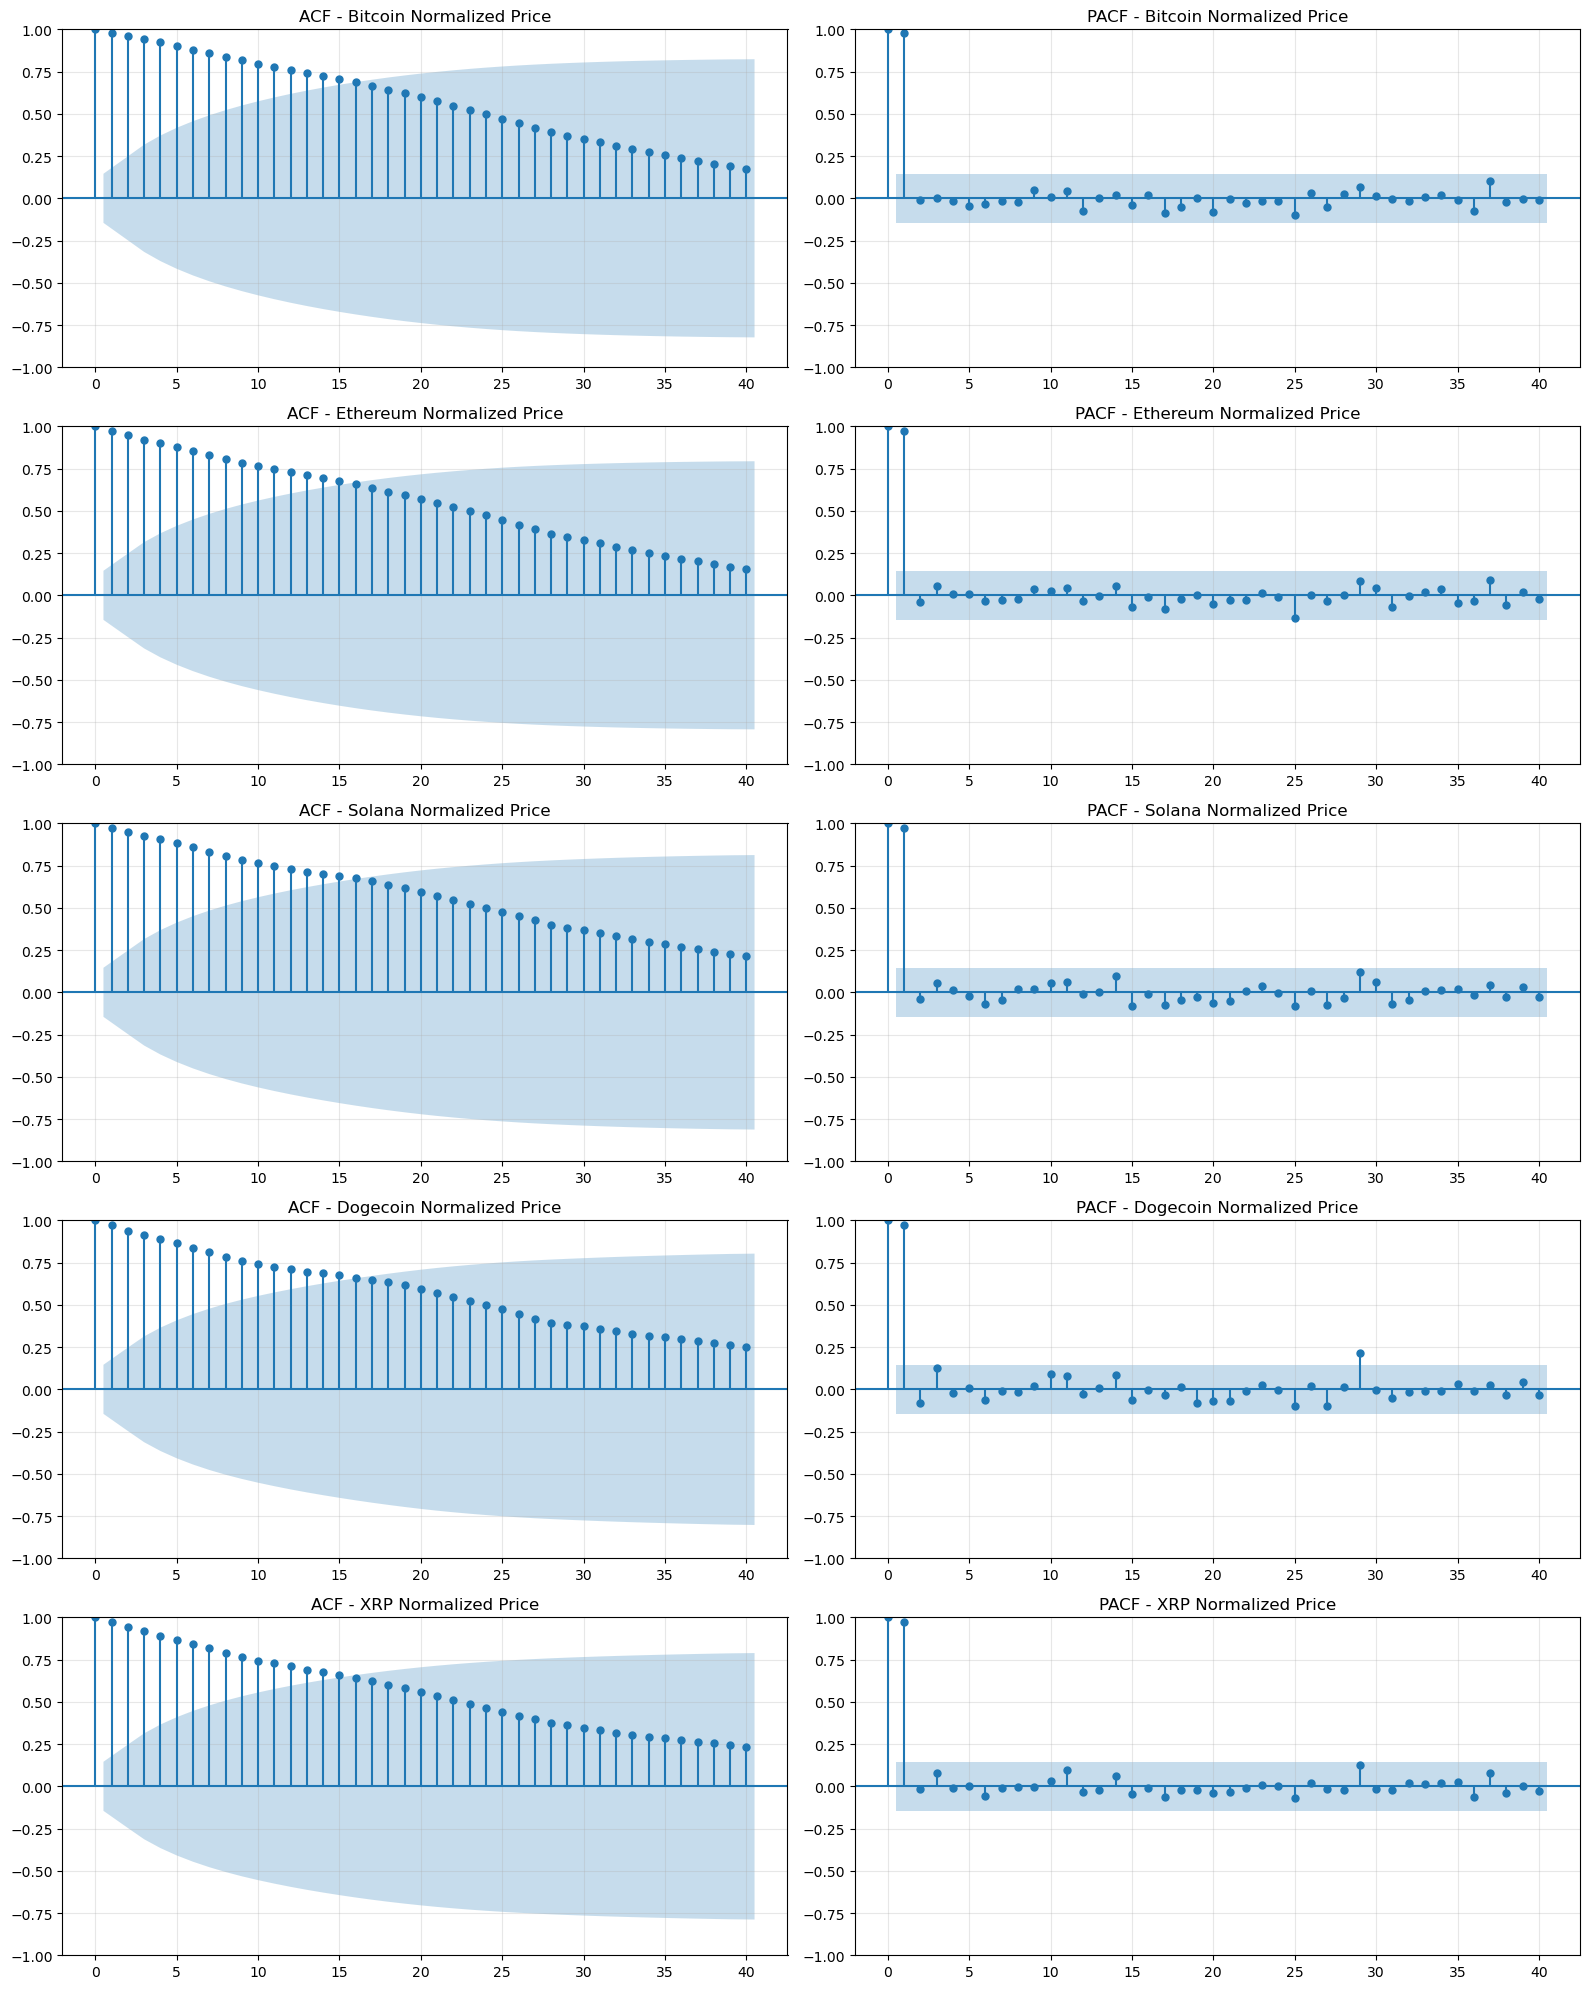

In [15]:
# ── ACF and PACF for each crypto's log returns ───────────────────────────────
n_lags = 40

fig, axes = plt.subplots(len(norm_6m.columns), 2, figsize=(16, 4 * len(norm_6m.columns)))

for i, coin in enumerate(norm_6m.columns):
    series = norm_6m[coin].dropna()
    plot_acf(series, lags=n_lags, ax=axes[i, 0], title=f"ACF - {coin} Normalized Price")
    plot_pacf(series, lags=n_lags, ax=axes[i, 1], title=f"PACF - {coin} Normalized Price", method="ywm")

plt.tight_layout()
plt.show()